# Импорт необходимых библиотек и вывод информации о датафрейме

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv("wikidata_universities_sample.csv") # получение данных

In [82]:
df.head(5) # вывод 5 первых строк

,university,coord,inception,universityLabel,countryLabel
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi


In [83]:
df.tail(5) # вывод 5 последних строк

,university,coord,inception,universityLabel,countryLabel
1995,http://www.wikidata.org/entity/Q848958,Point(139.490694 35.699503),1949-01-01T00:00:00Z,Tokyo Keizai University,Japan
1996,http://www.wikidata.org/entity/Q849611,Point(3.183333 6.466667),1983-01-01T00:00:00Z,Lagos State University,Nigeria
1997,http://www.wikidata.org/entity/Q849611,Point(3.2009 6.4651),1983-01-01T00:00:00Z,Lagos State University,Nigeria
1998,http://www.wikidata.org/entity/Q849751,Point(-79.503611111 43.773055555),1959-01-01T00:00:00Z,York University,Canada
1999,http://www.wikidata.org/entity/Q850247,Point(28.976018 41.01224),0425-01-01T00:00:00Z,University of Constantinople,Byzantine Empire


In [84]:
print("Размер таблицы, типы данных в ней, а также кол-во пропусков")
print("Размер -", df.shape)
print("Количество пропусков:")
print(df.isnull().sum())
print(df.info())

Размер таблицы, типы данных в ней, а также кол-во пропусков
Размер - (2000, 5)
Количество пропусков:
university           0
coord              217
inception           55
universityLabel      0
countryLabel         8
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   university       2000 non-null   object
 1   coord            1783 non-null   object
 2   inception        1945 non-null   object
 3   universityLabel  2000 non-null   object
 4   countryLabel     1992 non-null   object
dtypes: object(5)
memory usage: 78.3+ KB
None


In [85]:
df.drop_duplicates() # удаление дубликатов

# заполняем и удаляем пропуски

df.dropna(subset=['countryLabel']) # удаляем строки, где countryLabel is None

df["coord"] = df['coord'].fillna('Unknown') # заменяем значения coord в строках где они неизвестны

df

,university,coord,inception,universityLabel,countryLabel
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi
...,...,...,...,...,...
1995,http://www.wikidata.org/entity/Q848958,Point(139.490694 35.699503),1949-01-01T00:00:00Z,Tokyo Keizai University,Japan
1996,http://www.wikidata.org/entity/Q849611,Point(3.183333 6.466667),1983-01-01T00:00:00Z,Lagos State University,Nigeria
1997,http://www.wikidata.org/entity/Q849611,Point(3.2009 6.4651),1983-01-01T00:00:00Z,Lagos State University,Nigeria
1998,http://www.wikidata.org/entity/Q849751,Point(-79.503611111 43.773055555),1959-01-01T00:00:00Z,York University,Canada


In [86]:
def f(x):
    return str(x)[:4]

df.dropna(inplace=True)

df['inceptionyear'] = df['inception'].apply(f).astype(int)

pd.to_numeric('inceptionyear', errors='coerce')

df

,university,coord,inception,universityLabel,countryLabel,inceptionyear
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy,1887
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada,1967
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand,1986
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand,1960
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi,1997
...,...,...,...,...,...,...
1995,http://www.wikidata.org/entity/Q848958,Point(139.490694 35.699503),1949-01-01T00:00:00Z,Tokyo Keizai University,Japan,1949
1996,http://www.wikidata.org/entity/Q849611,Point(3.183333 6.466667),1983-01-01T00:00:00Z,Lagos State University,Nigeria,1983
1997,http://www.wikidata.org/entity/Q849611,Point(3.2009 6.4651),1983-01-01T00:00:00Z,Lagos State University,Nigeria,1983
1998,http://www.wikidata.org/entity/Q849751,Point(-79.503611111 43.773055555),1959-01-01T00:00:00Z,York University,Canada,1959


In [87]:
df.isnull().sum() # проверка

university         0
coord              0
inception          0
universityLabel    0
countryLabel       0
inceptionyear      0
dtype: int64

In [108]:
print("Количество уникальных стран - %d" % df["countryLabel"].nunique()) # количество уникальных стран

Количество уникальных стран - 181


In [109]:
print("Самая поздний год основания университета - %s" % df["inceptionyear"].max()) # максимальный год основания университета

Самая поздний год основания университета - 2013


In [110]:
print("Самая ранняя дата основания университета - %s" % df["inceptionyear"].min()) # минимальный год основания университета

Самая ранняя дата основания университета - 425


In [111]:
print("Медианный год основания - %s" % df["inceptionyear"].median().astype(int)) # медианный год основания
print("Средний год основания - %s" % df["inceptionyear"].mean().astype(int)) # средний год основания
print("Средний возраст ВУЗов - %s" % str(2025 - int(df["inceptionyear"].mean()))) # средний возраст ВУЗа

Медианный год основания - 1959
Средний год основания - 1928
Средний возраст ВУЗов - 97


In [113]:
df.sort_values(by = "inception") # сортировка данных по году основания университета

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age,age_group
1999,http://www.wikidata.org/entity/Q850247,Point(28.976018 41.01224),0425-01-01T00:00:00Z,University of Constantinople,Byzantine Empire,425,1600,Ancient
372,http://www.wikidata.org/entity/Q414464,Point(48.516666666 32.283333333),0531-01-01T00:00:00Z,Academy of Gondishapur,Rashidun Caliphate,531,1494,Ancient
371,http://www.wikidata.org/entity/Q414464,Point(48.516666666 32.283333333),0531-01-01T00:00:00Z,Academy of Gondishapur,Umayyad Caliphate,531,1494,Ancient
370,http://www.wikidata.org/entity/Q414464,Point(48.516666666 32.283333333),0531-01-01T00:00:00Z,Academy of Gondishapur,Sasanian Empire,531,1494,Ancient
369,http://www.wikidata.org/entity/Q414464,Point(48.516666666 32.283333333),0531-01-01T00:00:00Z,Academy of Gondishapur,Abbasid Caliphate,531,1494,Ancient
...,...,...,...,...,...,...,...,...
1699,http://www.wikidata.org/entity/Q3064322,Point(5.43991 43.23177),2012-01-01T00:00:00Z,Aix-Marseille University Faculty of Sciences,France,2012,13,Modern
1789,http://www.wikidata.org/entity/Q5461548,Point(-81.89415278 27.996825),2012-01-01T00:00:00Z,Florida Polytechnic University,United States,2012,13,Modern
995,http://www.wikidata.org/entity/Q3046238,Point(-16.727173 13.406532),2013-01-01T00:00:00Z,EUCLID,Central African Republic,2013,12,Modern
996,http://www.wikidata.org/entity/Q3046238,Point(-16.727173 13.406532),2013-01-01T00:00:00Z,EUCLID,The Gambia,2013,12,Modern


In [114]:
df.head(5) # очистка и преобразование данных

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age,age_group
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy,1887,138,Old
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada,1967,58,Modern
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand,1986,39,Modern
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand,1960,65,Modern
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi,1997,28,Modern


In [94]:
df["age"] = df["inceptionyear"].astype(int).apply(
    lambda year: 2025 - year if year != 0 else 0
)
# создание столбца с возрастом университета и его вычисление через лямбду
df.head(5)

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy,1887,138
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada,1967,58
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand,1986,39
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand,1960,65
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi,1997,28


In [95]:
# категориальный столбец age_group

df["age_group"] = df["age"].apply(
    lambda age: "Ancient" if age > 300 else ("Old" if age >= 100 else "Modern")
)

df.head(5)

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age,age_group
0,http://www.wikidata.org/entity/Q470997,Point(12.478932 41.882936),1887-01-01T00:00:00Z,Pontificio Ateneo Sant Anselmo,Italy,1887,138,Old
1,http://www.wikidata.org/entity/Q472167,Point(-97.153366666 49.890122222),1967-01-01T00:00:00Z,University of Winnipeg,Canada,1967,58,Modern
2,http://www.wikidata.org/entity/Q474969,Point(100.58646111 13.964875),1986-01-01T00:00:00Z,Rangsit University,Thailand,1986,39,Modern
3,http://www.wikidata.org/entity/Q476521,Point(100.49555 13.65155278),1960-01-01T00:00:00Z,King Mongkut's University of Technology Thonburi,Thailand,1960,65,Modern
4,http://www.wikidata.org/entity/Q477625,Point(33.993231 -11.421996),1997-01-01T00:00:00Z,Mzuzu University,Malawi,1997,28,Modern


In [96]:
df[df["age"] == df["age"].max()] # самые старые ВУЗы

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age,age_group
1999,http://www.wikidata.org/entity/Q850247,Point(28.976018 41.01224),0425-01-01T00:00:00Z,University of Constantinople,Byzantine Empire,425,1600,Ancient


In [97]:
df[df["age"] == df["age"].min()] # самые новые ВУЗы

,university,coord,inception,universityLabel,countryLabel,inceptionyear,age,age_group
995,http://www.wikidata.org/entity/Q3046238,Point(-16.727173 13.406532),2013-01-01T00:00:00Z,EUCLID,Central African Republic,2013,12,Modern
996,http://www.wikidata.org/entity/Q3046238,Point(-16.727173 13.406532),2013-01-01T00:00:00Z,EUCLID,The Gambia,2013,12,Modern
1721,http://www.wikidata.org/entity/Q1971174,Point(-3.169276168 51.479464371),2013-01-01T00:00:00Z,University of South Wales,United Kingdom,2013,12,Modern


In [98]:
print("Средний возраст - %.2f" % float(df["age"].mean().astype(int))) # средний возраст
print("Медианный возраст - %.2f" % float(df["age"].median().astype(int))) # медианный возраст

Средний возраст - 96.00
Медианный возраст - 65.00


In [99]:
group = df.groupby('countryLabel').size().sort_values(ascending=False).head(10) # 10 стран с наибольшим количеством университетов
group

countryLabel
United States                 315
Japan                         124
People's Republic of China    100
South Korea                    68
Russia                         61
United Kingdom                 56
Philippines                    55
Italy                          41
Ukraine                        41
Romania                        38
dtype: int64

In [100]:
country_mean_age = df.groupby("countryLabel")["age"].mean().round(0).sort_values(ascending=False) # сортировка стран по среднему возрасту университетов
country_mean_age.head(10) # вывод первых 10 стран

countryLabel
Byzantine Empire              1600.0
Abbasid Caliphate             1494.0
Rashidun Caliphate            1494.0
Umayyad Caliphate             1494.0
Sasanian Empire               1494.0
Kingdom of England             764.0
Holy Roman Empire              523.0
Prussia                        519.0
Margraviate of Brandenburg     519.0
Kingdom of Hungary             485.0
Name: age, dtype: float64

In [101]:
print("Страна с самой старой системой образования - %s" % country_mean_age.nlargest(1))

Страна с самой старой системой образования - countryLabel
Byzantine Empire    1600.0
Name: age, dtype: float64


In [102]:
print("Страна с самой молодой системой образования - %s" % country_mean_age.nsmallest(1))

Страна с самой молодой системой образования - countryLabel
Central African Republic    14.0
Name: age, dtype: float64


In [103]:
df["age_group"].value_counts() # кол-во университетов по возрастным категориям

age_group
Modern     1376
Old         485
Ancient      81
Name: count, dtype: int64

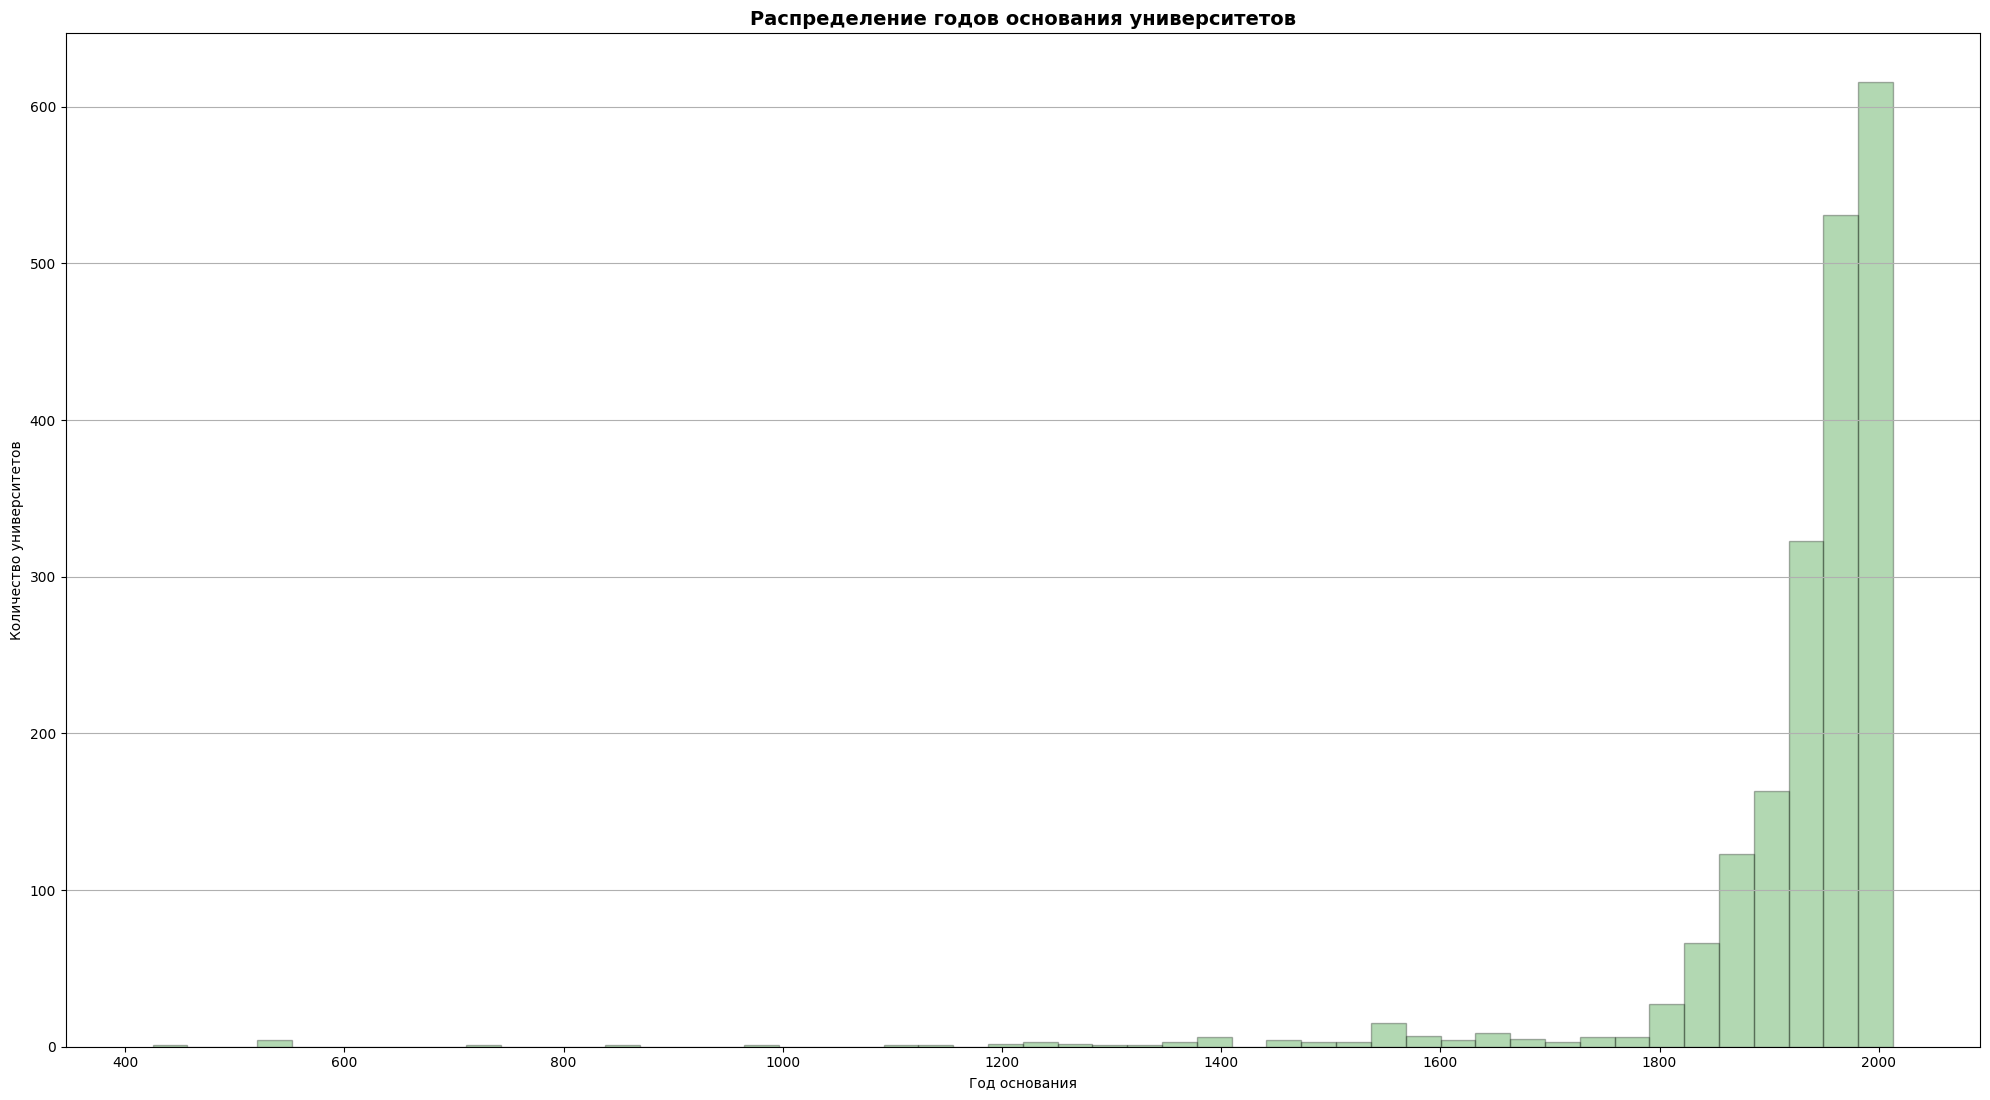

In [104]:
# гистограмма распределения годов основания
plt.figure(figsize = (20, 11.1))

plt.hist(df['inceptionyear'], bins = 50, color = 'green', edgecolor = 'black', alpha = 0.3)
plt.title('Распределение годов основания университетов', fontsize=14, fontweight='bold')

plt.xlabel('Год основания')
plt.ylabel('Количество университетов')

plt.grid(axis='y', alpha=1)
plt.tight_layout()

plt.show()

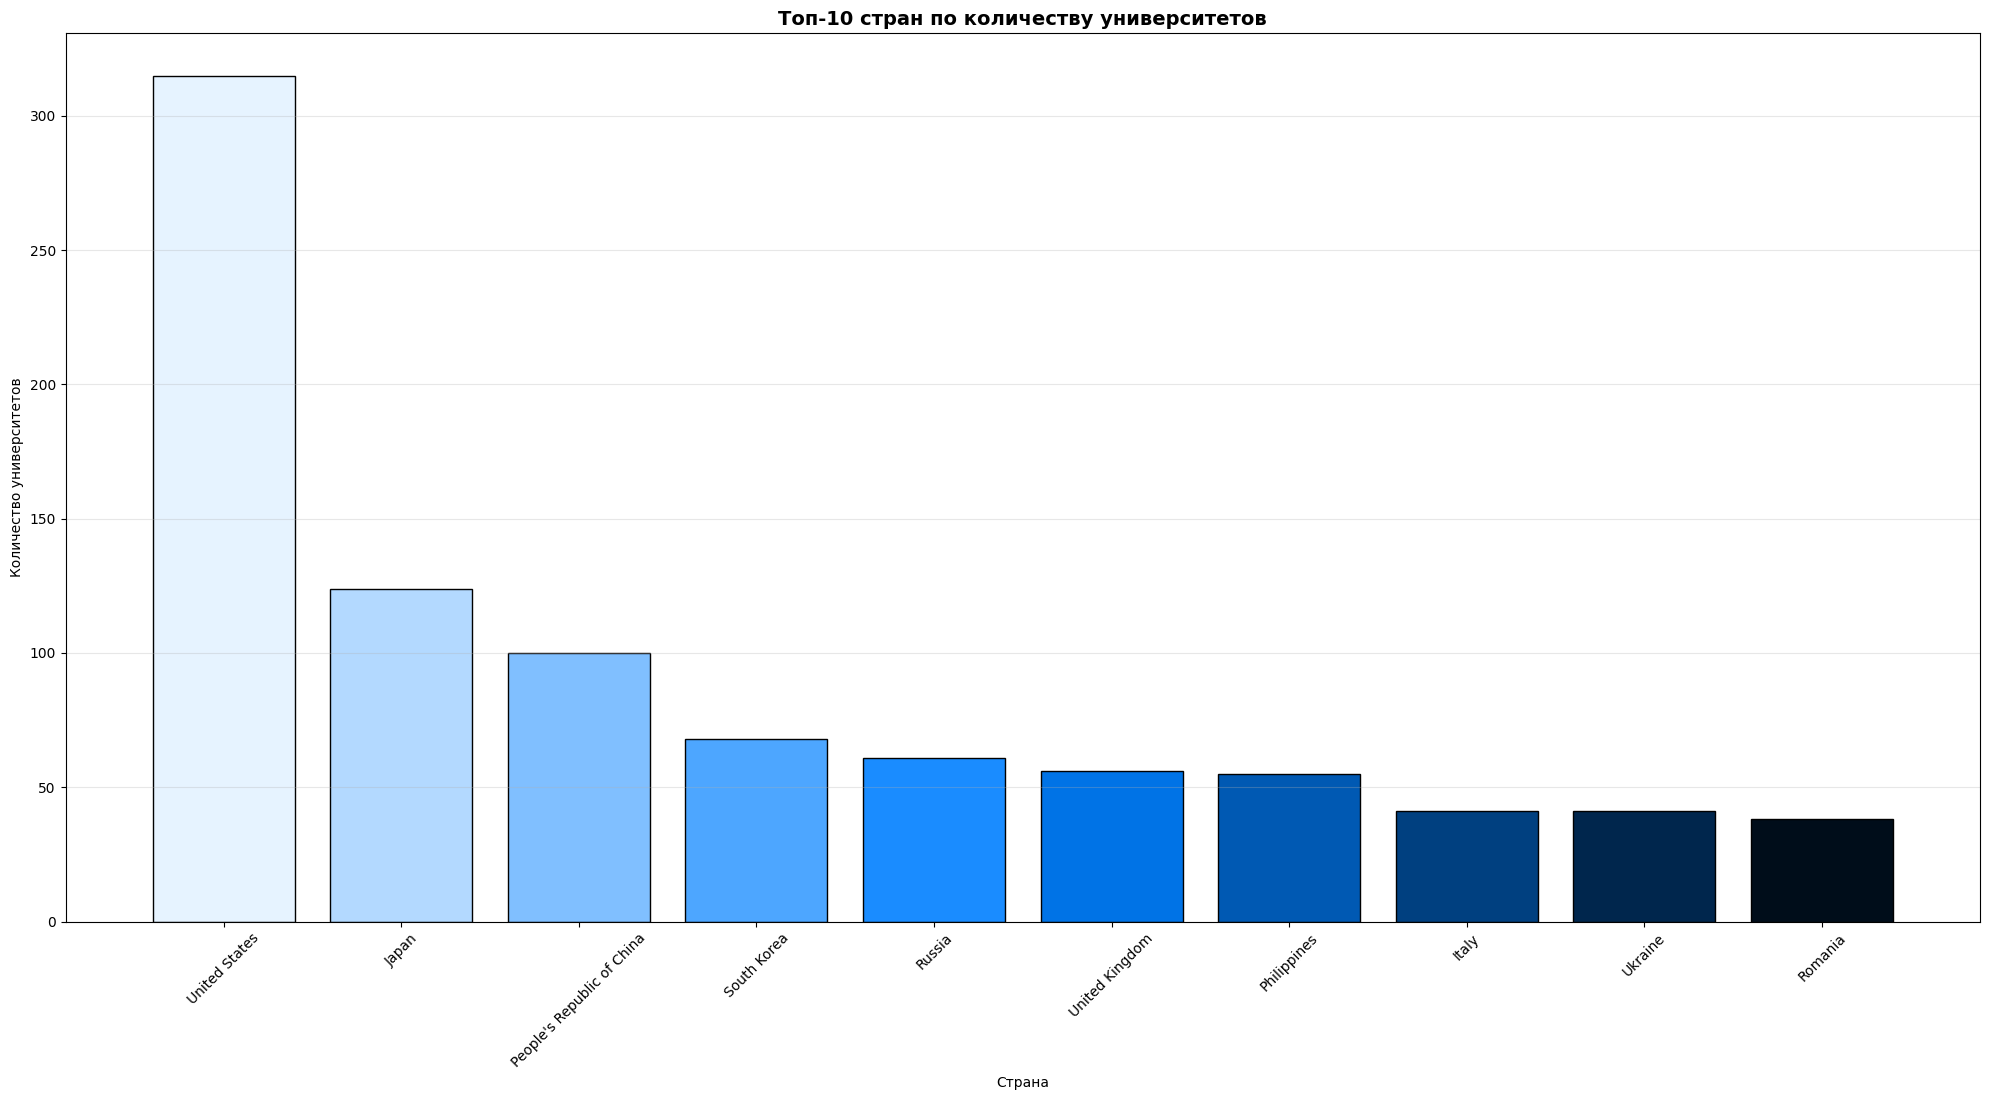

In [105]:
# столбчатая диаграмма топ-10 стран
plt.figure(figsize=(20, 11.1))
top_countries = df['countryLabel'].value_counts().head(10)

colors = ["#E6F3FF", "#B3D9FF", "#80BFFF", "#4DA6FF", "#1A8CFF", "#0073E6", "#0059B3", "#004080", "#00264D", "#000D1A"]

plt.bar(top_countries.index, top_countries.values, color = colors, edgecolor = 'black')

plt.title('Топ-10 стран по количеству университетов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Страна')
plt.ylabel('Количество университетов')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

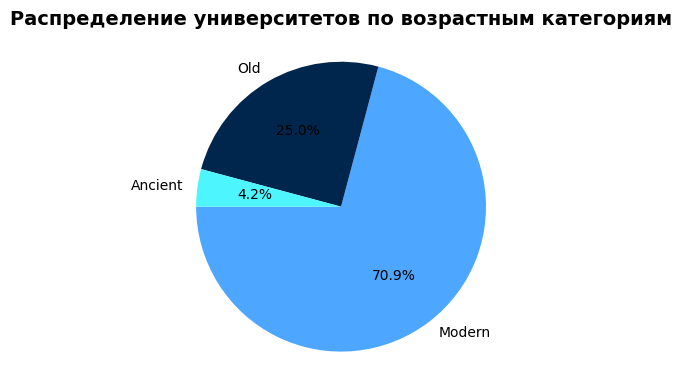

In [106]:
# круговая диаграмма распределения катерогий age-group
plt.figure(figsize=(4, 4))
age_group_counts = df['age_group'].value_counts()


age_colors = ["#4DA6FF", "#00264D", "#4DF6FF"]

plt.pie(age_group_counts.values, 
        labels = age_group_counts.index, 
        autopct = '%1.1f%%', 
        startangle = 180, 
        colors = age_colors)

plt.title('Распределение университетов по возрастным категориям', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()

plt.show()

Итоги и выводы:
1. По количеству университетов преобладают США, Япония и Китай.
2. Средний возраст ВУЗов составляет 74 года(а ЮФУ уже 110 лет!).
3. Наиболее активными годами были 1990-2010гг., так как в эти годы было основано большое количество университетов - до 175.
4. В мире преобладает категория университетов 'modern' - три четверти университетов были основаны менее 100 лет назад.